	# Revenue Analysis and Customer-Level Aggregation on UK E-Commerce Data
    

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [51]:

# Images
os.makedirs('images', exist_ok=True)

In [52]:
# Load dataset
df = pd.read_csv('data.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [53]:

df.shape

(541909, 8)

In [54]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [55]:
(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [56]:
# Convert InvoiceDate from text to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate'].min(), df['InvoiceDate'].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [57]:
df['Cancelled'] = df['InvoiceNo'].str.startswith('C')


In [58]:
cancelled = df[df['Cancelled']]
print('Cancelled rows:', cancelled.shape[0])
print('Cancelled orders:', cancelled['InvoiceNo'].nunique())

Cancelled rows: 9288
Cancelled orders: 3836


In [59]:
df_clean = df.dropna(subset=['CustomerID']).copy()

In [60]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [61]:
print('Rows before:', df.shape[0])
print('Rows after:', df_clean.shape[0])
print('Dropped:', df.shape[0] - df_clean.shape[0])

Rows before: 541909
Rows after: 406829
Dropped: 135080


In [62]:
returns = df_clean[df_clean['Quantity'] < 0]
df_sales = df_clean[df_clean['Quantity'] > 0].copy()

In [63]:
returns.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom,True
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,True
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom,True
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,True
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,True


In [64]:
df_sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False


In [65]:
print('Return rows:', returns.shape[0])
print('Sales rows:', df_sales.shape[0])

Return rows: 8905
Sales rows: 397924


In [66]:
df['InvoiceNo'].nunique()

25900

In [67]:
(df['Quantity'] < 0).sum()

10624

In [68]:
df_sales['Revenue'] = df_sales['Quantity'] * df_sales['UnitPrice']

In [69]:
print('Total revenue:', df_sales['Revenue'].sum())


Total revenue: 8911407.904


In [70]:
# Revenue = Quantity * UnitPrice
df_sales[['Quantity', 'UnitPrice', 'Revenue']].head(10)

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,32,1.69,54.08


In [71]:
# Aggregate by customer: total revenue and number of unique orders
customer_stats = df_sales.groupby('CustomerID').agg(
    TotalRevenue=('Revenue', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique')
)

# Average order value = total revenue / number of orders
customer_stats['AvgOrderValue'] = customer_stats['TotalRevenue'] / customer_stats['TotalOrders']

# Sort customers from highest to lowest revenue
customer_stats = customer_stats.sort_values('TotalRevenue', ascending=False)

print('Number of customers:', customer_stats.shape[0])
customer_stats.head(10)

Number of customers: 4339


,TotalRevenue,TotalOrders,AvgOrderValue
CustomerID,,,
14646,280206.02,74,3786.567838
18102,259657.30,60,4327.621667
17450,194550.79,46,4229.365000
16446,168472.50,2,84236.250000
14911,143825.06,201,715.547562
12415,124914.53,21,5948.310952
14156,117379.63,55,2134.175091
17511,91062.38,31,2937.496129
16029,81024.84,63,1286.108571


In [72]:
# Mean of customers' AOV 
print('Mean of customer AOV:', round(customer_stats['AvgOrderValue'].mean(), 2))

Mean of customer AOV: 419.05


In [73]:
top5_revenue = customer_stats['TotalRevenue'].head(5).sum()
total_revenue = customer_stats['TotalRevenue'].sum()

print('Top 5 customers revenue:', round(top5_revenue, 2))
print('Top 5 share:', round(top5_revenue / total_revenue * 100, 2), '%')
customer_stats.head(5)

Top 5 customers revenue: 1046711.67
Top 5 share: 11.75 %


,TotalRevenue,TotalOrders,AvgOrderValue
CustomerID,,,
14646,280206.02,74,3786.567838
18102,259657.30,60,4327.621667
17450,194550.79,46,4229.365000
16446,168472.50,2,84236.250000
14911,143825.06,201,715.547562


In [74]:
# Aggregate by country
country_stats = df_sales.groupby('Country').agg(
    TotalRevenue=('Revenue', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique'))
# Revenue share of each country
country_stats['RevenueShare'] = country_stats['TotalRevenue'] / country_stats['TotalRevenue'].sum() * 100

# Sort from highest to lowest revenue
country_stats = country_stats.sort_values('TotalRevenue', ascending=False)

In [75]:
country_stats.head(10)

,TotalRevenue,TotalOrders,RevenueShare
Country,,,
United Kingdom,7308391.554,16649,82.011638
Netherlands,285446.340,95,3.203156
EIRE,265545.900,260,2.979842
Germany,228867.140,457,2.568249
France,209024.050,389,2.345578
Australia,138521.310,57,1.554427
Spain,61577.110,90,0.690992
Switzerland,56443.950,51,0.633390
Belgium,41196.340,98,0.462288


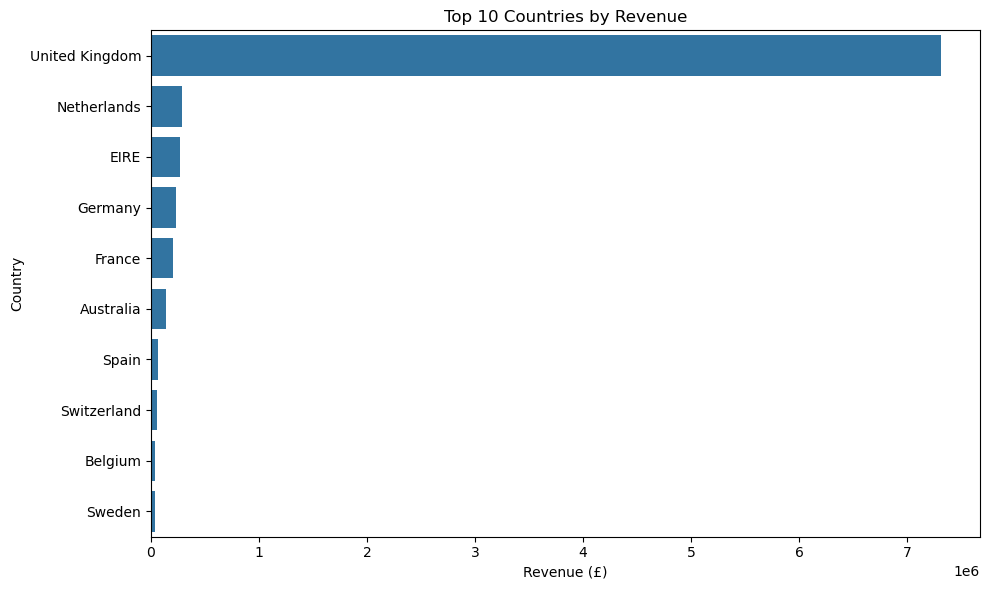

In [76]:
top10_countries = country_stats.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top10_countries['TotalRevenue'], y=top10_countries.index)
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('images/top10_countries.png')
plt.show()


In [77]:
df_sales['YearMonth'] = df_sales['InvoiceDate'].dt.to_period('M')


In [78]:
monthly_revenue = df_sales.groupby('YearMonth')['Revenue'].sum()

In [79]:
monthly_revenue.sort_values(ascending=False).head(3)

YearMonth
2011-11    1161817.380
2011-10    1039318.790
2011-09     952838.382
Freq: M, Name: Revenue, dtype: float64

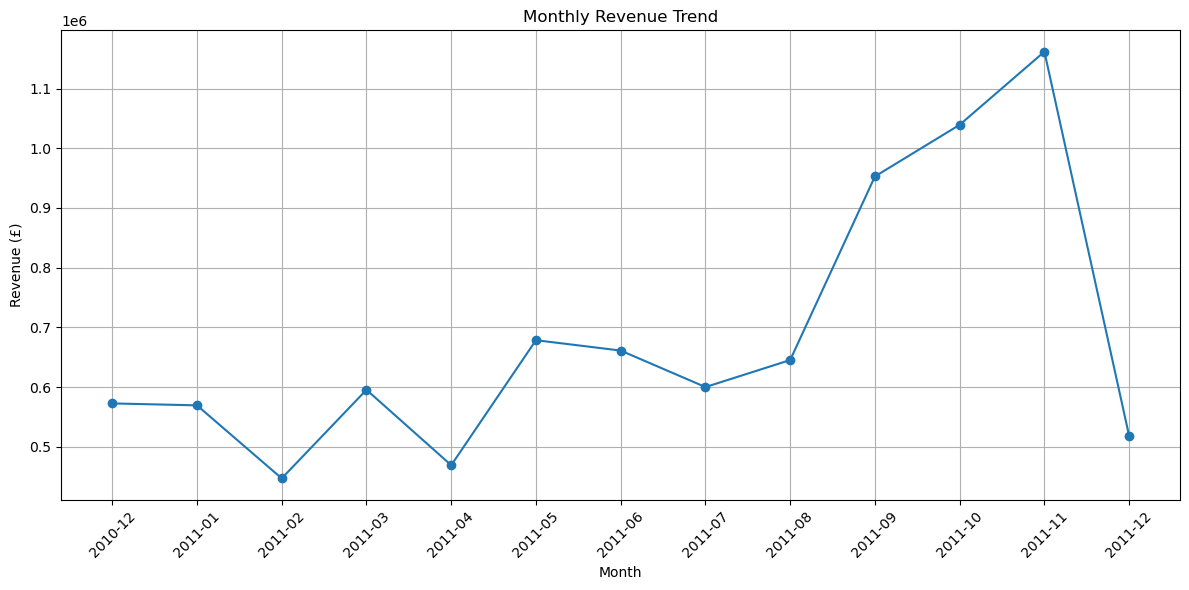

In [80]:
# Line chart: monthly revenue trend
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig('images/monthly_revenue.png')
plt.show()

In [81]:
# Total quantity sold per product, top 20
top20_products = (
    df_sales.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

In [82]:
top20_products.head(20)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
PACK OF 12 LONDON TISSUES             25345
PACK OF 60 PINK PAISLEY CAKE CASES    24264
BROCADE RING PURSE                    22963
VICTORIAN GLASS HANGING T-LIGHT       22433
ASSORTED COLOURS SILK FAN             21876
RED  HARMONICA IN BOX                 20975
JUMBO BAG PINK POLKADOT               20165
SMALL POPCORN HOLDER                  18252
LUNCH BAG RED RETROSPOT               17697
60 TEATIME FAIRY CAKE CASES           17689
Name: Quantity, dtype: int64

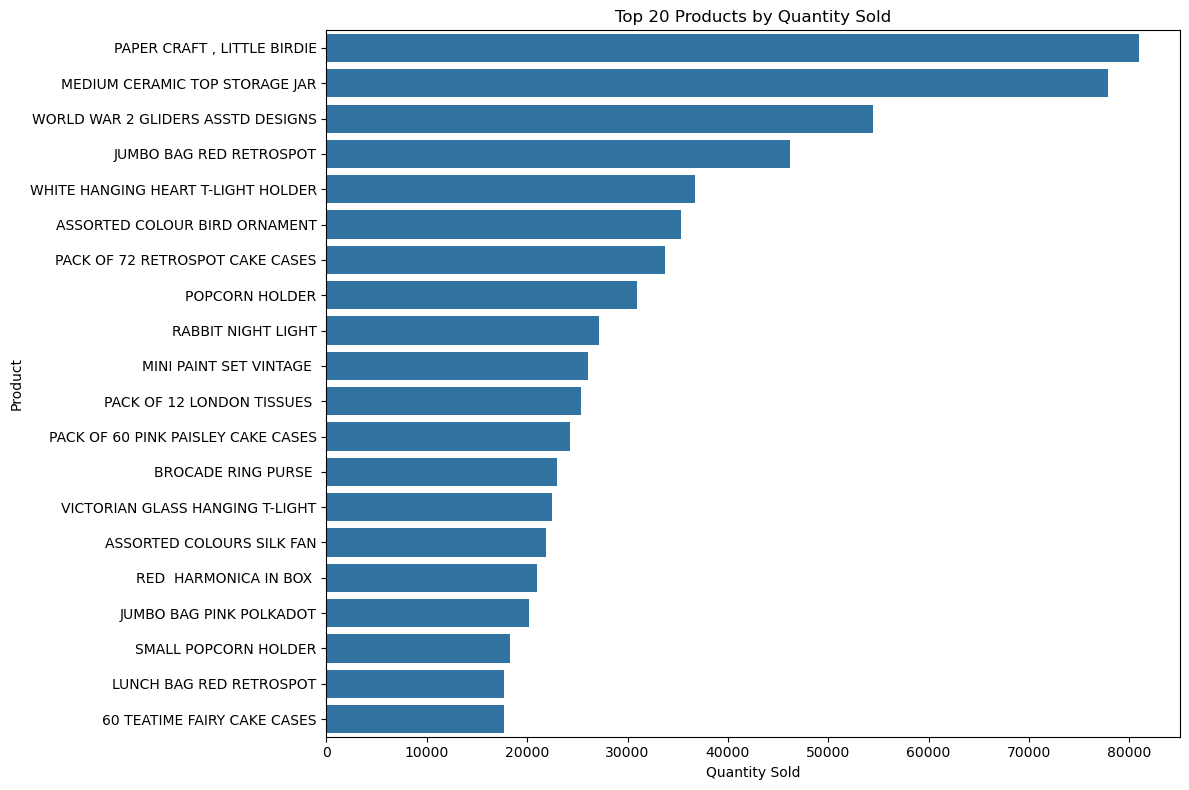

In [83]:
# Horizontal bar chart: top 20 products by quantity
plt.figure(figsize=(12, 8))
sns.barplot(x=top20_products.values, y=top20_products.index)
plt.title('Top 20 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('images/top20_products.png')
plt.show()



In [84]:
print(df['Description'].value_counts().head(5))

Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
Name: count, dtype: int64


In [85]:
total_orders = df_clean.groupby('Country')['InvoiceNo'].nunique()

In [86]:
cancelled_orders = df_clean[df_clean['Cancelled']].groupby('Country')['InvoiceNo'].nunique()

In [87]:
return_rate = pd.DataFrame({
    'TotalOrders': total_orders,
    'CancelledOrders': cancelled_orders
}).fillna(0)

In [88]:
return_rate['ReturnRate'] = return_rate['CancelledOrders'] / return_rate['TotalOrders'] * 100

In [89]:
overall_rate = return_rate['CancelledOrders'].sum() / return_rate['TotalOrders'].sum() * 100

In [90]:
return_rate['HighReturn'] = return_rate['ReturnRate'] > overall_rate

return_rate = return_rate.sort_values('ReturnRate', ascending=False)

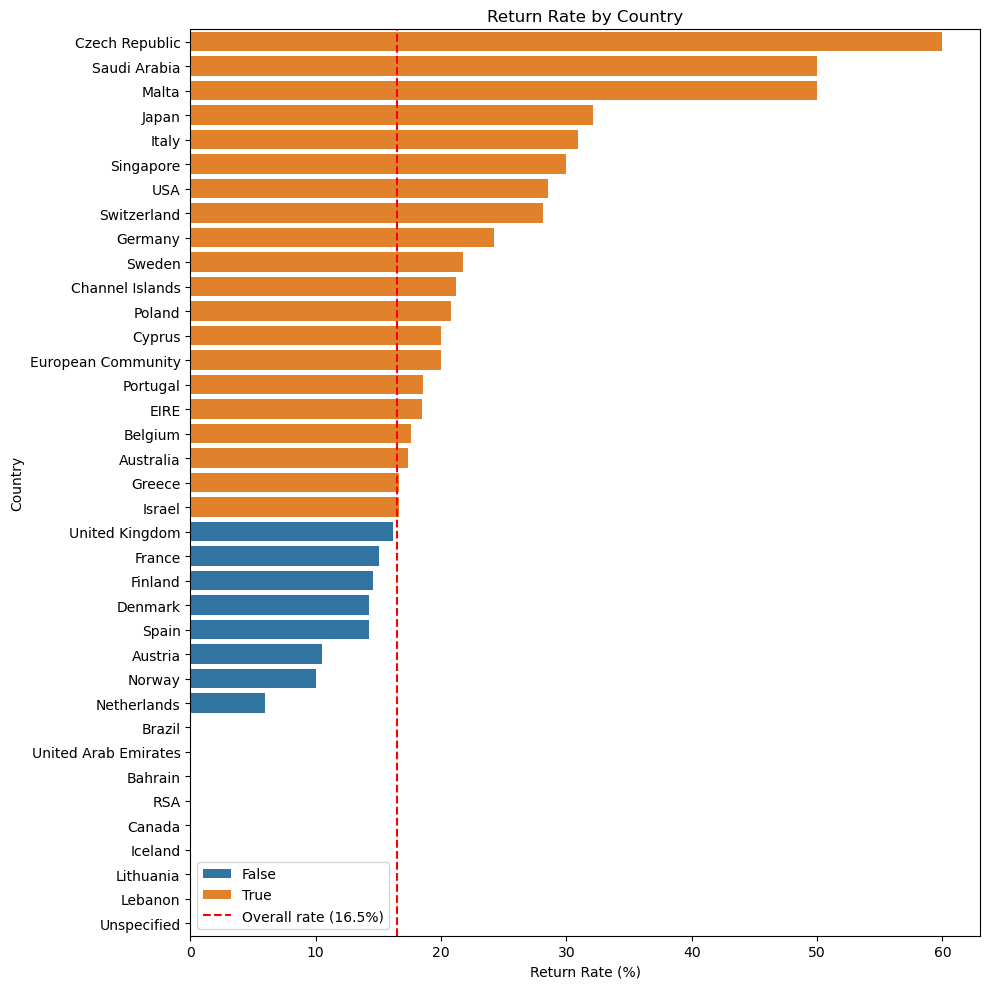

Overall return rate: 16.47 %


,TotalOrders,CancelledOrders,ReturnRate,HighReturn
Country,,,,
Czech Republic,5,3.0,60.000000,True
Saudi Arabia,2,1.0,50.000000,True
Malta,10,5.0,50.000000,True
Japan,28,9.0,32.142857,True
Italy,55,17.0,30.909091,True
Singapore,10,3.0,30.000000,True
USA,7,2.0,28.571429,True
Switzerland,71,20.0,28.169014,True
Germany,603,146.0,24.212272,True


In [91]:
# Horizontal bar chart: return rate by country
plt.figure(figsize=(10, 10))
sns.barplot(data=return_rate, x='ReturnRate', y=return_rate.index, hue='HighReturn', dodge=False)
plt.axvline(overall_rate, color='red', linestyle='--', label=f'Overall rate ({overall_rate:.1f}%)')
plt.title('Return Rate by Country')
plt.xlabel('Return Rate (%)')
plt.ylabel('Country')
plt.legend()
plt.tight_layout()
plt.savefig('images/return_rate_by_country.png')
plt.show()

print('Overall return rate:', round(overall_rate, 2), '%')
return_rate[return_rate['HighReturn']]

In [92]:
top10_customers = customer_stats.head(10).index

In [93]:
top10_sales = df_sales[df_sales['CustomerID'].isin(top10_customers)]

In [94]:
top10_monthly = top10_sales.pivot_table(
    index='YearMonth',
    columns='CustomerID',
    values='Revenue',
    aggfunc='sum',
    fill_value=0
)

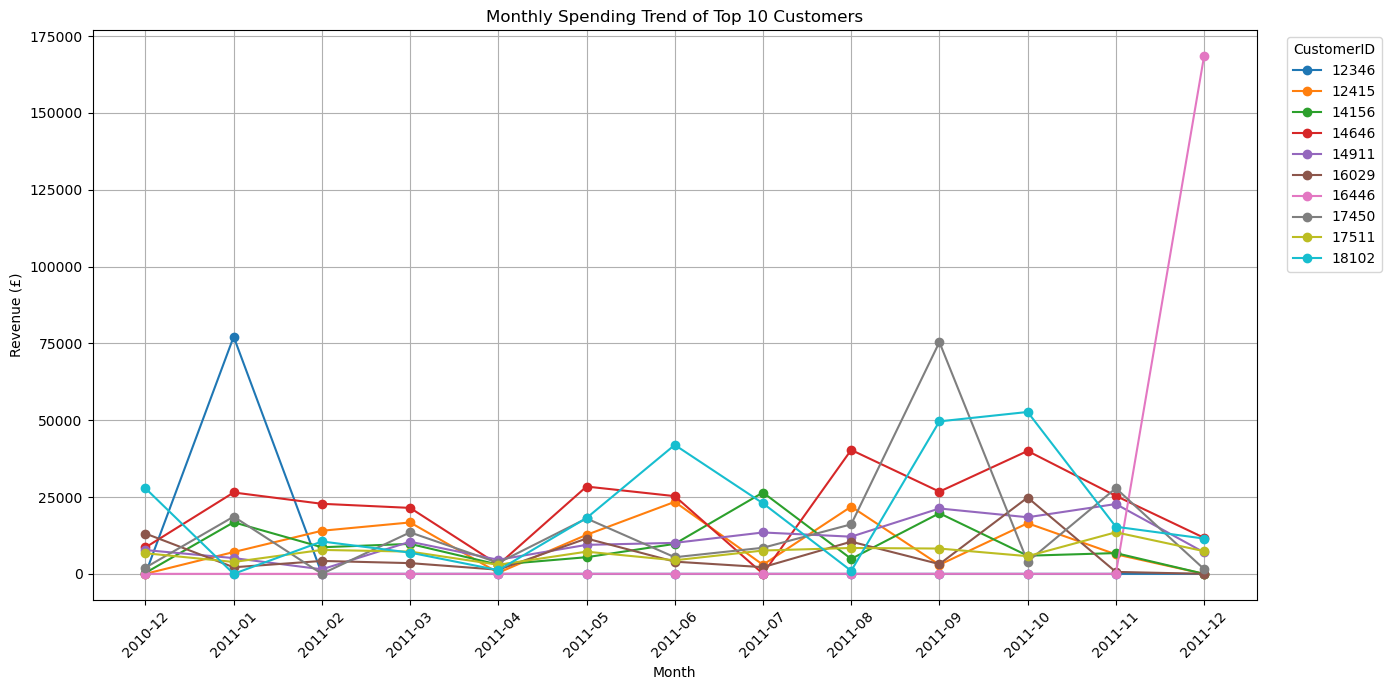

CustomerID,12346,12415,14156,14646,14911,16029,16446,17450,17511,18102
YearMonth,,,,,,,,,,
2010-12,0.0,0.00,322.20,8591.88,7737.94,13112.52,0.0,2028.84,6711.08,27834.61
2011-01,77183.6,7092.98,16774.72,26476.68,5129.47,2139.39,0.0,18620.20,3862.14,0.00
2011-02,0.0,14022.92,8655.33,22797.46,1471.19,4200.36,0.0,0.00,7783.64,10535.48
2011-03,0.0,16726.84,9744.62,21462.40,10452.18,3487.08,0.0,13500.50,7238.58,6909.32
2011-04,0.0,350.00,2998.18,2976.56,4572.32,1340.40,0.0,3585.04,2941.80,1196.96
2011-05,0.0,12691.16,5412.18,28408.14,9436.68,11496.51,2.9,18025.68,7213.16,18165.74
2011-06,0.0,23426.81,9757.79,25288.99,10078.20,3969.60,0.0,5405.48,4415.44,41959.44
2011-07,0.0,2955.01,26464.99,26.02,13463.58,2170.08,0.0,8485.14,7590.01,22949.76
2011-08,0.0,21880.44,4871.89,40327.81,12095.49,10471.30,0.0,16119.46,8419.62,985.92


In [96]:
# Line chart
plt.figure(figsize=(14, 7))
for customer in top10_monthly.columns:
    plt.plot(top10_monthly.index.astype(str), top10_monthly[customer], marker='o', label=str(customer))

plt.title('Monthly Spending Trend of Top 10 Customers')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.legend(title='CustomerID', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig('images/top10_customers_monthly.png')
plt.show()

top10_monthly

In [97]:
products_per_invoice = df_sales.groupby(['Country', 'InvoiceNo'])['StockCode'].nunique()

In [98]:
# Average basket size per country (average unique products per order)
basket_size = (
    products_per_invoice
    .groupby(level='Country')
    .mean()
    .sort_values(ascending=False)
)

print('Overall avg basket size:', round(products_per_invoice.mean(), 2))
basket_size.round(2).head(10)

Overall avg basket size: 20.93


Country
RSA            58.00
Israel         49.00
Lebanon        45.00
Cyprus         37.44
Switzerland    36.10
USA            35.80
Brazil         32.00
Singapore      31.14
Unspecified    29.88
Norway         29.69
Name: StockCode, dtype: float64